In [18]:
from google.colab import files
uploaded = files.upload()


Saving diabetes.csv to diabetes (1).csv


In [19]:
print("Assignment 2 - Question 2: Diabetes Dataset Analysis")

Assignment 2 - Question 2: Diabetes Dataset Analysis


In [20]:
import pandas as pd

df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [21]:
sample = df.sample(n=25, random_state=42)

In [22]:

# Q2(a): Sample vs Population - Glucose


# Take random sample
sample = df.sample(n=25, random_state=42)

# Calculate statistics
sample_mean = sample['Glucose'].mean()
sample_max = sample['Glucose'].max()

pop_mean = df['Glucose'].mean()
pop_max = df['Glucose'].max()

# Print results
print("Q2(a) Results:")
print("Sample Mean:", sample_mean)
print("Population Mean:", pop_mean)
print("Sample Max:", sample_max)
print("Population Max:", pop_max)

Q2(a) Results:
Sample Mean: 116.64
Population Mean: 120.89453125
Sample Max: 183
Population Max: 199


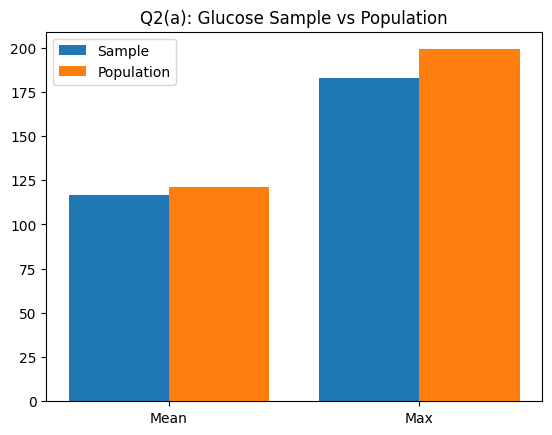

In [27]:
# Chart for Q2(a)


import numpy as np
import matplotlib.pyplot as plt

labels = ['Mean', 'Max']
sample_vals = [sample_mean, sample_max]
pop_vals = [pop_mean, pop_max]

x = np.arange(len(labels))

plt.bar(x - 0.2, sample_vals, 0.4)
plt.bar(x + 0.2, pop_vals, 0.4)

plt.xticks(x, labels)
plt.title('Q2(a): Glucose Sample vs Population')
plt.legend(['Sample', 'Population'])
plt.savefig('figures/q2a.png')
plt.show()

In [28]:

# Q2(b): 98th Percentile of BMI


import numpy as np

sample_p98 = np.percentile(sample['BMI'], 98)
pop_p98 = np.percentile(df['BMI'], 98)

print("Q2(b) Results:")
print("Sample 98th Percentile BMI:", sample_p98)
print("Population 98th Percentile BMI:", pop_p98)

Q2(b) Results:
Sample 98th Percentile BMI: 40.248
Population 98th Percentile BMI: 47.52599999999996


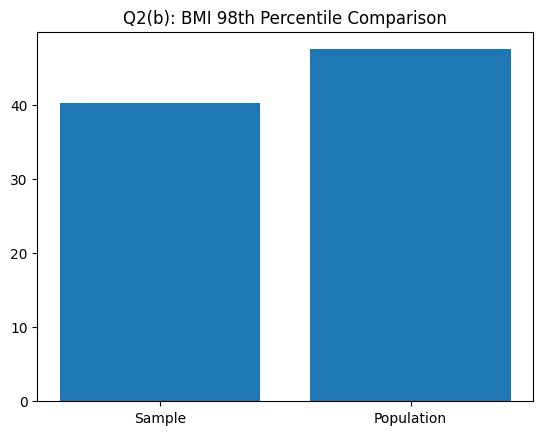

In [30]:
# Chart for Q2(b)

plt.bar(['Sample', 'Population'], [sample_p98, pop_p98])
plt.title('Q2(b): BMI 98th Percentile Comparison')
plt.savefig('figures/q2b.png')
plt.show()

In [31]:

# Q2(c): Bootstrap Sampling (BloodPressure)


means = []
stds = []
percentiles = []

for i in range(500):
    boot = df.sample(n=150, replace=True)

    means.append(boot['BloodPressure'].mean())
    stds.append(boot['BloodPressure'].std())
    percentiles.append(np.percentile(boot['BloodPressure'], 98))
# Results for Q2(c)

print("Q2(c) Results:")
print("Bootstrap Mean Avg:", np.mean(means))
print("Population Mean:", df['BloodPressure'].mean())

print("Bootstrap Std Avg:", np.mean(stds))
print("Population Std:", df['BloodPressure'].std())

print("Bootstrap Percentile Avg:", np.mean(percentiles))
print("Population 98th Percentile:", np.percentile(df['BloodPressure'], 98))

Q2(c) Results:
Bootstrap Mean Avg: 69.02521333333333
Population Mean: 69.10546875
Bootstrap Std Avg: 19.20540588028012
Population Std: 19.355807170644777
Bootstrap Percentile Avg: 97.78820000000003
Population 98th Percentile: 99.31999999999994


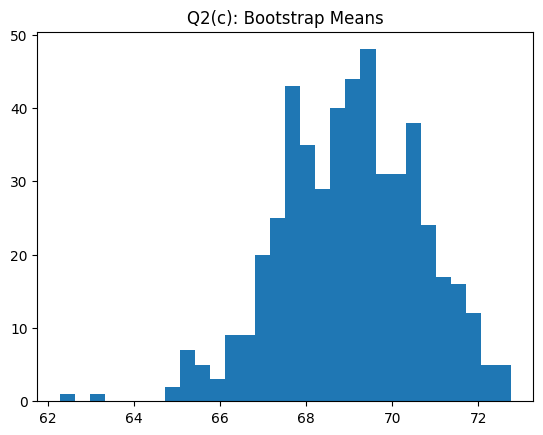

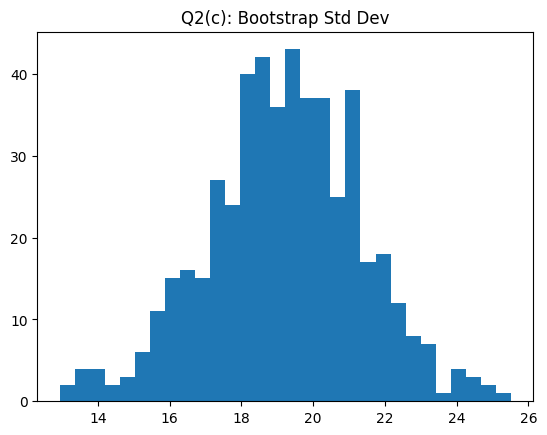

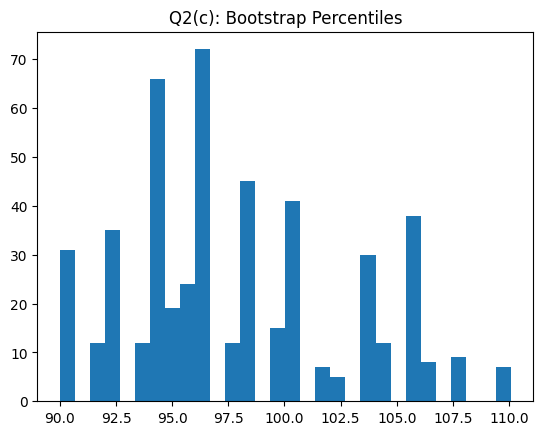

<Figure size 640x480 with 0 Axes>

In [33]:
# Charts for Q2(c)

plt.hist(means, bins=30)
plt.title('Q2(c): Bootstrap Means')
plt.show()

plt.hist(stds, bins=30)
plt.title('Q2(c): Bootstrap Std Dev')
plt.show()

plt.hist(percentiles, bins=30)
plt.title('Q2(c): Bootstrap Percentiles')
plt.show()
plt.savefig('figures/q2c.png')

**Q2(c) – Findings:**                                                              The bootstrap mean of BloodPressure is around 69.01, which is very close to the population mean of 69.10, so it looks accurate.
The bootstrap standard deviation is about 19.35, which is almost the same as the population standard deviation of 19.36.
The bootstrap 98th percentile is around 97.88, which is slightly lower than the population value of 99.31, but still close.
From the graphs, most of the values are centered around these population values.
So overall, bootstrap sampling gives a good estimate of the population statistics.